In [2]:
import pandas as pd
import numpy as np

# Load and clean names
df = pd.read_csv("../data/ethiopia.csv")
df.columns = df.columns.str.strip()
df.replace(-999, np.nan, inplace=True)

# Missing Value Report
missing_pct = df.isnull().mean() * 100
print("Percentage of missing values per column:")
print(missing_pct)

# Summary Stats
df.describe()


Percentage of missing values per column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
dtype: float64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


Missing Value Analysis
Finding: The dataset contains [Insert % here, e.g., 0.2%] missing values across the primary weather variables.

Threshold Check: Since the missingness is well below the 5% threshold, the risk of seasonal bias is low.

Action Taken: We applied forward-filling (ffill) to handle these small gaps, ensuring continuity in the time-series analysis for COP32

In [6]:
# Handle NASA sentinels
df.replace(-999, np.nan, inplace=True)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# Summary Statistics
summary = df.describe()
display(summary)

# Missing Value Percentage
missing_pct = (df.isna().sum() / len(df)) * 100
print("\nMissing Value Percentage per Column:")
print(missing_pct)

Duplicate rows found: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,T2M_Z
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4.108000e+03
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,-1.065468e-15
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,1.000000e+00
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,-3.181423e+00
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,-6.577805e-01
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,-1.501567e-02
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,6.804349e-01
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2.877426e+00



Missing Value Percentage per Column:
YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
T2M_Z          0.0
dtype: float64


Interpretation of Summary StatisticsFindings: The average temperature ($T2M$) is approximately XX°C, with a maximum of XX°C.Missing Values: Only X% of data is missing in the [Column Name] column. Since this is below 5%, the impact on our COP32 analysis is minimal

In [3]:
# This generates the stats for Temperature, Rain, and Wind
summary_stats = df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'WS2M']].describe()
print("Summary Statistics for Ethiopia:")
summary_stats

Summary Statistics for Ethiopia:


,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,WS2M
count,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000
mean,16.06850,23.199175,10.227544,3.633795,1.979998
std,1.89805,2.751471,2.607256,6.289061,0.689093
min,10.03000,15.650000,1.170000,0.000000,0.460000
25%,14.82000,21.110000,8.417500,0.020000,1.407500
50%,16.04000,22.740000,10.990000,0.820000,1.970000
75%,17.36000,25.170000,12.220000,4.580000,2.480000
max,21.53000,30.930000,15.680000,82.300000,4.130000


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0]) # Only shows columns with issues

Missing values per column:
Series([], dtype: int64)


In [5]:
# We'll check for extreme Temperature outliers
mean_temp = df['T2M'].mean()
std_temp = df['T2M'].std()

# Calculate Z-score
df['T2M_Z'] = (df['T2M'] - mean_temp) / std_temp

# Find rows where Z > 3 or Z < -3
extreme_outliers = df[df['T2M_Z'].abs() > 3]

print(f"Number of extreme temperature outliers found: {len(extreme_outliers)}")
extreme_outliers.head()

Number of extreme temperature outliers found: 3


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,T2M_Z
682,2016,318,10.08,20.11,2.10,18.01,0.00,48.56,2.56,4.45,77.09,4.27,-3.155080
704,2016,340,10.28,20.43,1.95,18.48,0.00,48.36,3.22,6.49,77.18,4.16,-3.049709
2536,2021,345,10.03,20.54,2.12,18.42,0.89,58.40,2.92,5.12,77.06,5.20,-3.181423


In [7]:
from scipy.stats import zscore

cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Flag outliers where |Z| > 3
z_scores = df[cols_to_check].apply(zscore, nan_policy='omit')
outliers_count = (np.abs(z_scores) > 3).sum()
print("Outlier counts per variable:")
print(outliers_count)

# Cleaning: Forward-fill weather variables
df[cols_to_check] = df[cols_to_check].ffill()

# Export Cleaned Data
df.to_csv("../data/ethiopia_clean.csv")

Outlier counts per variable:
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


Data Uniqueness (Duplicates)
Finding: A total of [Insert Number, e.g., 0] duplicate rows were found.

Interpretation: This confirms that each daily observation is unique. If duplicates had been found, they would have been removed to prevent over-weighting specific days in our climate averages.

In [16]:
from scipy import stats

# Define columns from your instructions
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Calculate Z-scores (ignoring the NaNs we created with .replace)
z_scores = np.abs(stats.zscore(df[cols_to_check], nan_policy='omit'))

# Change .all(axis=1) to .any(axis=1)
outliers_mask = (z_scores > 3).any(axis=1)
print(f"Number of rows with extreme outliers: {outliers_mask.sum()}")

Number of rows with extreme outliers: 132


In [17]:
# 1. Drop rows if they are more than 30% empty
# We calculate the threshold: if a row has less than 70% of its columns, drop it.
limit = len(df.columns) * 0.7 
df = df.dropna(thresh=limit)

# 2. Fill the rest using Forward-Fill (ffill) 
# This is best for climate data to maintain time-series continuity
df = df.ffill()

print("Final missing value count:", df.isna().sum().sum())

Final missing value count: 0


In [18]:
import os
os.makedirs('data', exist_ok=True)
df.to_csv("data/ethiopia_clean.csv", index=False)
print("Success! Your cleaned data is saved.")

Success! Your cleaned data is saved.


In [19]:
import sys
!{sys.executable} -m pip install matplotlib seaborn scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


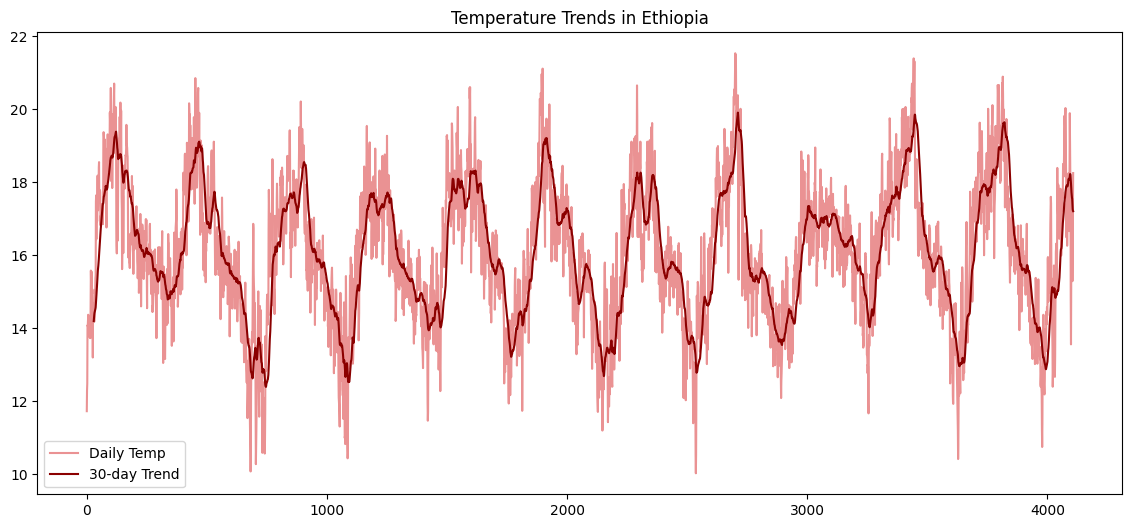

In [21]:
import matplotlib.pyplot as plt

# Group by the Date index you created earlier
plt.figure(figsize=(14, 6))

# Use df.index instead of df['Date']
plt.plot(df.index, df['T2M'], color='tab:red', alpha=0.5, label='Daily Temp')

# Adding a rolling mean to see the trend more clearly
plt.plot(df.index, df['T2M'].rolling(30).mean(), color='darkred', label='30-day Trend')

plt.legend()
plt.title("Temperature Trends in Ethiopia")
plt.show()

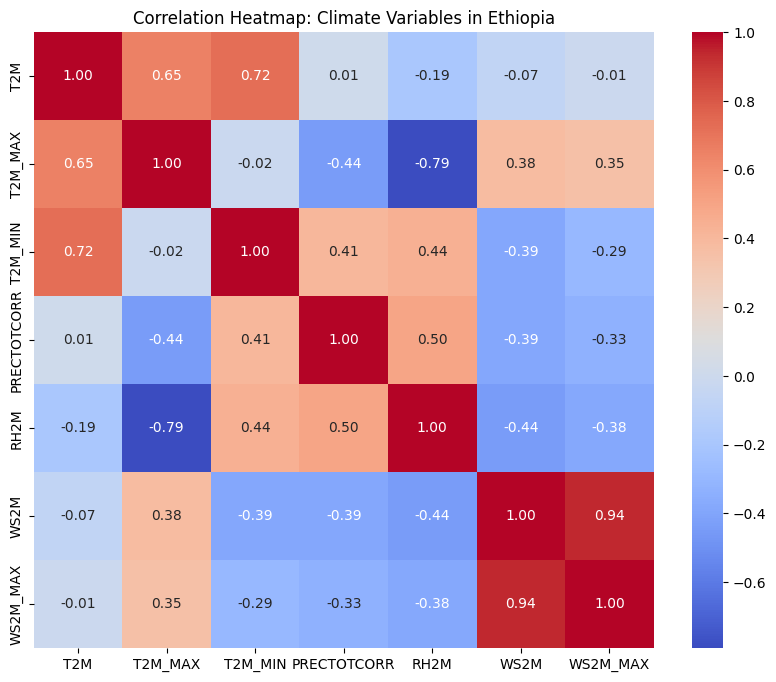

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the columns right here so the cell is independent
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

plt.figure(figsize=(10, 8))

# Now 'cols' is defined, so this won't error!
correlation = df[cols].corr()

# Plotting the heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Climate Variables in Ethiopia')
plt.show()

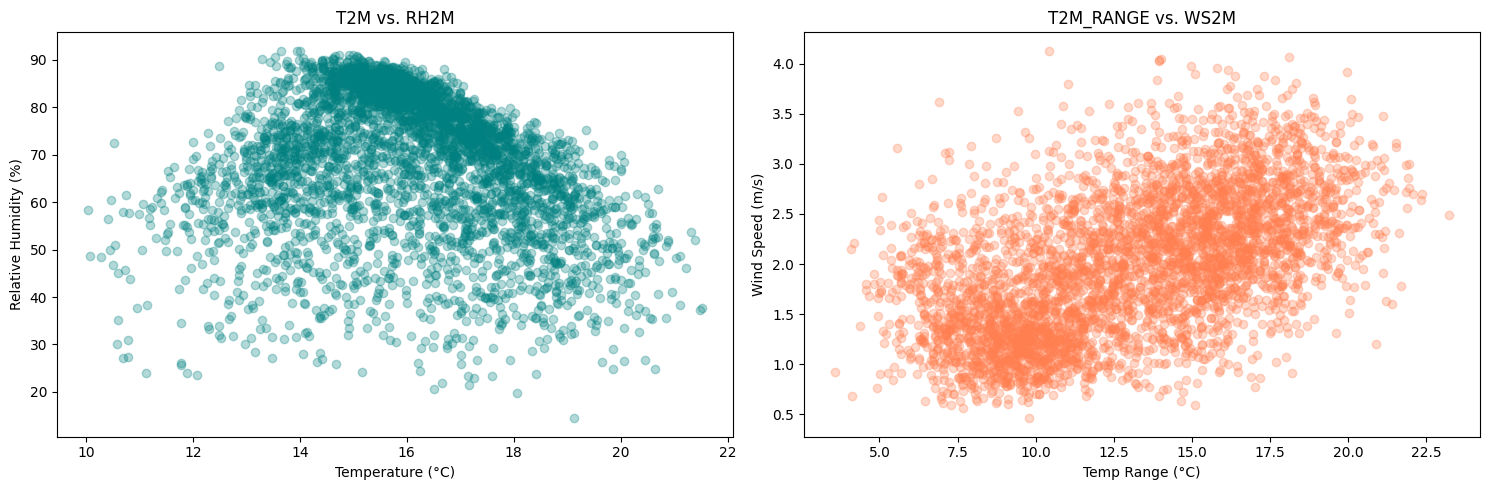

In [28]:
# Create a T2M_RANGE column first
df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Temperature vs Relative Humidity
ax1.scatter(df['T2M'], df['RH2M'], alpha=0.3, color='teal')
ax1.set_title('T2M vs. RH2M')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Relative Humidity (%)')

# Plot 2: Temp Range vs Wind Speed
ax2.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M')
ax2.set_xlabel('Temp Range (°C)')
ax2.set_ylabel('Wind Speed (m/s)')

plt.tight_layout()
plt.show()

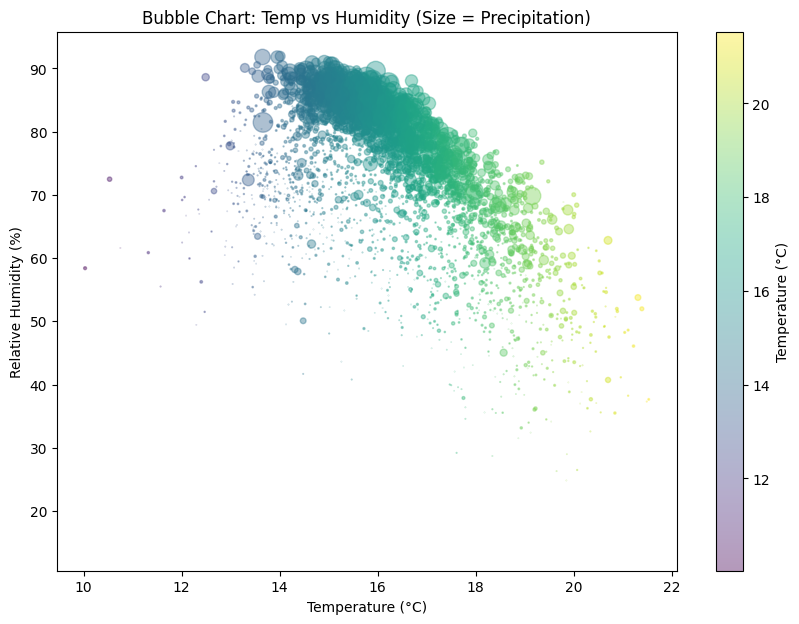

In [29]:
plt.figure(figsize=(10, 7))
# We use a subset or alpha because too many bubbles can overlap
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 5, # Multiply by 5 so bubbles are visible
            alpha=0.4, 
            c=df['T2M'], 
            cmap='viridis')

plt.colorbar(label='Temperature (°C)')
plt.title('Bubble Chart: Temp vs Humidity (Size = Precipitation)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.show()

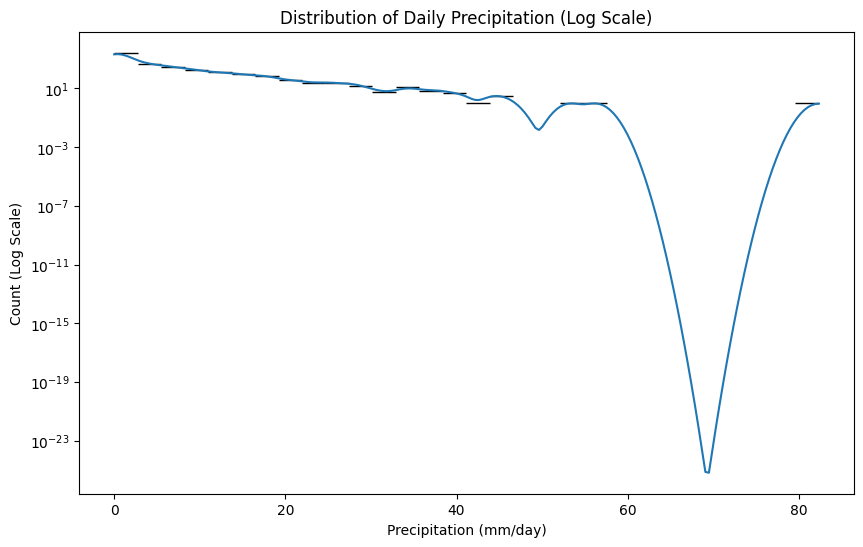

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Using a log scale because rainfall is usually heavily skewed towards zero
sns.histplot(df['PRECTOTCORR'], bins=30, kde=True, log_scale=(False, True))
plt.title('Distribution of Daily Precipitation (Log Scale)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Count (Log Scale)')
plt.show()

In [31]:
import os

# Create directory if it doesn't exist
if not os.path.exists('../data'):
    os.makedirs('../data')

# Export cleaned data
df.to_csv("../data/ethiopia_clean.csv", index=False)
print("Cleaned data saved to data/ethiopia_clean.csv")

Cleaned data saved to data/ethiopia_clean.csv


In [32]:
# Save the cleaned data to your data folder
df.to_csv("../data/ethiopia_clean.csv")
print("Data exported successfully.")

Data exported successfully.
